# Decision Tree Model on Titanic Dataset

This section explains the libraries used for building and visualizing the model.

## Importing Required Libraries

NumPy and Pandas are used for data handling and preprocessing. DecisionTreeClassifier is used to build the classification model, and Matplotlib with plot_tree helps in visualizing how the decision tree makes decisions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

## Loading the Dataset

The Titanic dataset is loaded using Pandas from a CSV file into a DataFrame. The head() function is used to display the first few rows, helping us understand the structure and contents of the data.

In [3]:
df=  pd.read_csv('Titanic.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis (EDA)

EDA is performed to understand the structure, distribution, and relationships in the dataset. It helps identify missing values, data types, and patterns before building the model.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


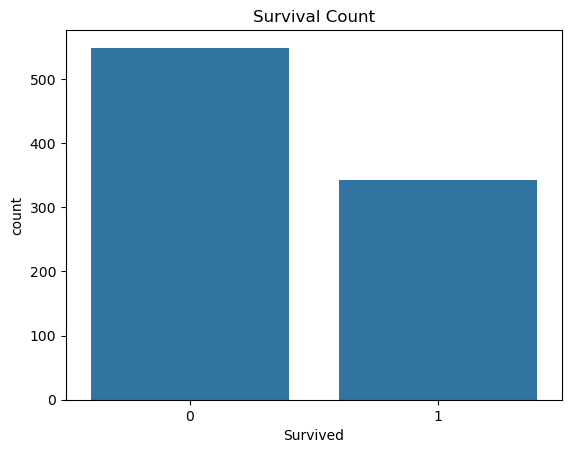

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

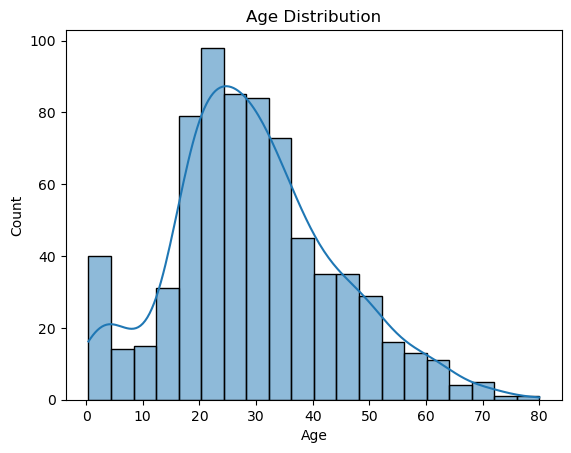

In [6]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

## Feature Selection

Relevant features are selected based on their importance in predicting survival. Features like Sex, Pclass, Age, and Fare are chosen as they have strong influence on survival.

In [11]:
features = ['Sex', 'Pclass', 'Age', 'Fare']
X = df[features]
y = df['Survived']

## Fixing Data for Scaling

Categorical values like 'male' and 'female' are converted into numerical form before applying scaling. This is necessary because scaling techniques only work with numerical data.

In [15]:
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

In [16]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

C:\Users\mohit\AppData\Local\Temp\ipykernel_8024\1423775592.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\mohit\AppData\Local\Temp\ipykernel_8024\1423775592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [17]:
features = ['Sex', 'Pclass', 'Age', 'Fare']
X = df[features]

## Pipeline

A pipeline is created to combine feature scaling and model training into a single structured workflow. This ensures that preprocessing and model steps are applied consistently.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier())
])

## Train-Test Split

The dataset is split into training and testing sets to evaluate the model's performance on unseen data.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Hyperparameter Tuning

GridSearchCV is used to find the best parameters for the Decision Tree model. This improves model performance by selecting optimal settings.

In [30]:
from sklearn.model_selection import GridSearchCV

params = {
    'model__max_depth': [3,5,7,10],
    'model__min_samples_split': [2,5,10]
}

grid = GridSearchCV(pipeline, params, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', DecisionTreeClassifier())]),
             param_grid={'model__max_depth': [3, 5, 7, 10],
                         'model__min_samples_split': [2, 5, 10]})

## Model Training with Best Parameters

The Decision Tree model is trained using the best parameters obtained from hyperparameter tuning.

In [23]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

## Selecting Best Model

The best model is obtained from GridSearchCV using the best combination of parameters. This model gives the highest performance.

## Model Prediction

The trained model is used to make predictions on the test data. These predictions are compared with actual values to evaluate performance.

## Model Evaluation

The accuracy of the model is calculated to measure how well it predicts survival. The result is shown in both decimal and percentage form.

## Decision Tree Visualization

The decision tree is visualized to understand how the model makes decisions based on input features. It shows the splitting conditions clearly.

## Saving the Model

The trained model is saved as a .pkl file using joblib. This allows the model to be reused later without retraining.

In [24]:
from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Accuracy (%): {accuracy*100:.2f}%")

Accuracy: 0.80
Accuracy (%): 79.89%


## Decision Tree Visualization

The trained decision tree is visualized to understand how the model makes decisions.

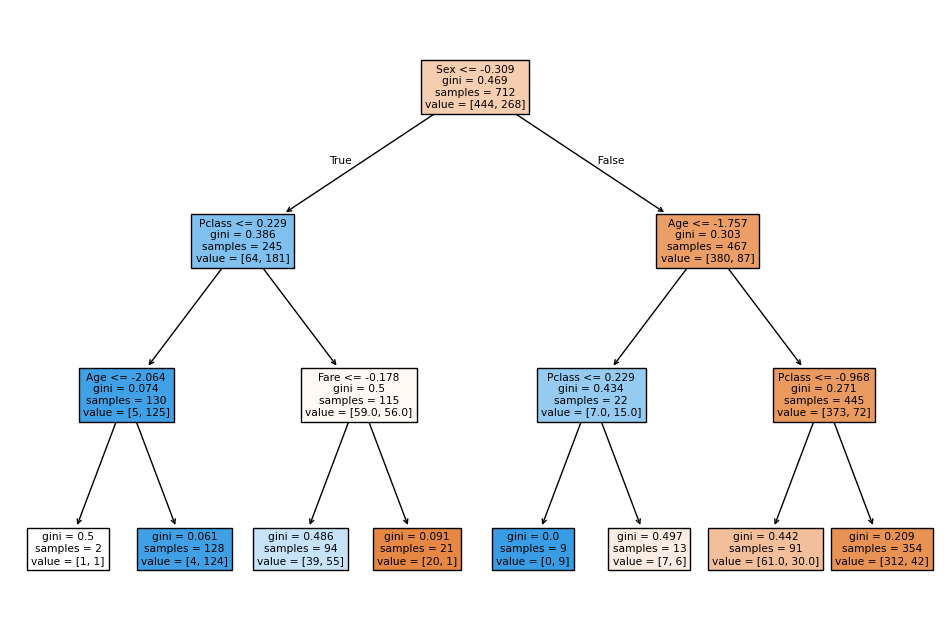

In [25]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(best_model, feature_names=features, filled=True)
plt.show()

## Saving the Model

The trained Decision Tree model is saved as a .pkl file using joblib. This allows the model to be reused later without retraining.

In [27]:
import joblib

joblib.dump(best_model, "titanic_decision_tree.pkl")

['titanic_decision_tree.pkl']